In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [11]:
def arrival_rates(Ward, t):
    if Ward == 'A':
        return -(1/3650)*t**2 + (1/10)*t
    elif Ward == 'B':
        return 1/5*(-(1/3650)*t**2 + (1/10)*t)
    elif Ward == 'C':
        return 6
    else:
        raise ValueError("Invalid ward name. Use 'A', 'B', or 'C'.")
    
def length_of_stay(Ward):
    if Ward == 'A':
        mu = np.log(4*np.sqrt(2))
        sigma = np.log(2)
    elif Ward == 'B':
        mu = np.log(6*np.sqrt(2))
        sigma = np.log(2)
    elif Ward == 'C':
        mu = np.log(5*np.sqrt(2))
        sigma = np.log(2)
    else:
        raise ValueError("Invalid ward name. Use 'A', 'B', or 'C'.")
    
    return np.random.lognormal(mean=mu, sigma=sigma)


In [24]:
import heapq

n_beds = 75
np.random.seed(42)  # For reproducibility


def next_arrival_time(ward, t_now, horizon=365.0):
    """Sample next arrival time for ward at or after t_now."""
    if ward == 'C':
        lam = arrival_rates('C', t_now)
        if lam <= 0:
            return np.inf
        return t_now + np.random.exponential(1.0 / lam)

    # NHPP thinning for time-varying rates in A and B
    # Max rates over [0, 365]: A ~ 9.125, B ~ 1.825
    lam_max = 9.2 if ward == 'A' else 1.9
    t = t_now
    while t < horizon:
        t += np.random.exponential(1.0 / lam_max)
        if t >= horizon:
            return np.inf
        lam_t = max(arrival_rates(ward, t), 0.0)
        if np.random.rand() < lam_t / lam_max:
            return t
    return np.inf


def simulate_one_year(capacity, horizon=365.0):
    """
    Event-driven simulation with fixed beds per ward.
    Rules:
    - A patients use A beds, else relocated
    - B patients use B beds; if B full, try A; else relocated
    - C patients use C beds, else relocated
    """
    wards = ['A', 'B', 'C']

    # Occupancy and discharge event queues
    occ = {w: 0 for w in wards}
    discharges = {w: [] for w in wards}

    # Statistics
    arrivals = {w: 0 for w in wards}
    relocated = {w: 0 for w in wards}
    transferred_B_to_A = 0

    # Time-average occupancy
    occ_area = {w: 0.0 for w in wards}

    # First arrival events
    next_arr = {w: next_arrival_time(w, 0.0, horizon) for w in wards}

    t = 0.0
    while t < horizon:
        # Next discharge across wards
        next_dis = {
            w: (min(discharges[w]) if discharges[w] else np.inf)
            for w in wards
        }

        # Find next event
        next_time = min(min(next_arr.values()), min(next_dis.values()))
        if not np.isfinite(next_time):
            break

        # Accumulate occupancy integral on [t, next_time)
        dt = max(0.0, min(next_time, horizon) - t)
        for w in wards:
            occ_area[w] += occ[w] * dt

        t = next_time

        # Process all discharges at time t
        for w in wards:
            n_before = len(discharges[w])
            discharges[w] = [d for d in discharges[w] if d > t + 1e-12]
            n_discharged = n_before - len(discharges[w])
            occ[w] -= n_discharged

        # Process arrivals at time t (can be multiple wards)
        for w in wards:
            if abs(next_arr[w] - t) <= 1e-12:
                arrivals[w] += 1

                if w == 'A':
                    if occ['A'] < capacity['A']:
                        stay = length_of_stay('A')
                        occ['A'] += 1
                        discharges['A'].append(t + stay)
                    else:
                        relocated['A'] += 1

                elif w == 'B':
                    if occ['B'] < capacity['B']:
                        stay = length_of_stay('B')
                        occ['B'] += 1
                        discharges['B'].append(t + stay)
                    elif occ['A'] < capacity['A']:
                        # Transfer intensive patient to A
                        stay = length_of_stay('A')
                        occ['A'] += 1
                        discharges['A'].append(t + stay)
                        transferred_B_to_A += 1
                    else:
                        relocated['B'] += 1

                else:  # ward C
                    if occ['C'] < capacity['C']:
                        stay = length_of_stay('C')
                        occ['C'] += 1
                        discharges['C'].append(t + stay)
                    else:
                        relocated['C'] += 1

                # Schedule next arrival for that ward
                next_arr[w] = next_arrival_time(w, t, horizon)

    mean_occ = {w: occ_area[w] / horizon for w in wards}
    total_relocated = relocated['A'] + relocated['B'] + relocated['C']

    return {
        'arrivals': arrivals,
        'relocated': relocated,
        'transferred_B_to_A': transferred_B_to_A,
        'total_relocated': total_relocated,
        'mean_occ': mean_occ,
    }


def evaluate_distribution(capacity, n_simulations=100):
    """Run repeated years for a fixed capacity split and aggregate metrics."""
    runs = [simulate_one_year(capacity) for _ in range(n_simulations)]

    wards = ['A', 'B', 'C']
    arrivals = {w: np.array([r['arrivals'][w] for r in runs]) for w in wards}
    relocated = {w: np.array([r['relocated'][w] for r in runs]) for w in wards}
    mean_occ = {w: np.array([r['mean_occ'][w] for r in runs]) for w in wards}
    transferred = np.array([r['transferred_B_to_A'] for r in runs])
    total_relocated = np.array([r['total_relocated'] for r in runs])

    block_prob = {
        w: np.mean(np.where(arrivals[w] > 0, relocated[w] / arrivals[w], 0.0))
        for w in wards
    }

    summary = {
        'capacity': capacity,
        'block_prob': block_prob,
        'mean_occ': {w: float(np.mean(mean_occ[w])) for w in wards},
        'mean_relocated': {w: float(np.mean(relocated[w])) for w in wards},
        'mean_total_relocated': float(np.mean(total_relocated)),
        'mean_transferred_B_to_A': float(np.mean(transferred)),
        'occ_series': mean_occ,
    }
    return summary


def optimize_bed_distribution(total_beds=75, n_simulations=60, step=5, min_beds=(5, 5, 5)):
    """Grid search for fixed (A,B,C) capacity that minimizes mean relocations."""
    min_A, min_B, min_C = min_beds
    best = None

    for A in range(min_A, total_beds - min_B - min_C + 1, step):
        for B in range(min_B, total_beds - A - min_C + 1, step):
            C = total_beds - A - B
            if C < min_C:
                continue
            cap = {'A': A, 'B': B, 'C': C}
            res = evaluate_distribution(cap, n_simulations=n_simulations)
            if (best is None) or (res['mean_total_relocated'] < best['mean_total_relocated']):
                best = res

    return best


# 1) Evaluate one baseline split
baseline_capacity = {'A': 30, 'B': 15, 'C': 30}
baseline_results = evaluate_distribution(baseline_capacity, n_simulations=100)

print('Baseline capacity:', baseline_capacity)
for w in ['A', 'B', 'C']:
    bp = baseline_results['block_prob'][w]
    print(f"Blocking probability Ward {w}: {bp:.3f} ({bp*100:.1f}%)")
print(f"Mean transferred patients (B->A): {baseline_results['mean_transferred_B_to_A']:.1f}")
print(f"Mean total relocated patients: {baseline_results['mean_total_relocated']:.1f}")

# 2) Search for better fixed distribution
best_results = optimize_bed_distribution(total_beds=n_beds, n_simulations=1, step=1, min_beds=(5, 5, 5))
optimal_distribution = best_results['capacity']

print('\nBest fixed bed distribution (coarse grid search):', optimal_distribution)
for w in ['A', 'B', 'C']:
    bp = best_results['block_prob'][w]
    print(f"Best split blocking probability Ward {w}: {bp:.3f} ({bp*100:.1f}%)")
print(f"Best split mean transferred patients (B->A): {best_results['mean_transferred_B_to_A']:.1f}")
print(f"Best split mean total relocated patients: {best_results['mean_total_relocated']:.1f}")


Baseline capacity: {'A': 30, 'B': 15, 'C': 30}
Blocking probability Ward A: 0.442 (44.2%)
Blocking probability Ward B: 0.118 (11.8%)
Blocking probability Ward C: 0.457 (45.7%)
Mean transferred patients (B->A): 40.2
Mean total relocated patients: 2037.8

Best fixed bed distribution (coarse grid search): {'A': 31, 'B': 5, 'C': 39}
Best split blocking probability Ward A: 0.454 (45.4%)
Best split blocking probability Ward B: 0.364 (36.4%)
Best split blocking probability Ward C: 0.287 (28.7%)
Best split mean transferred patients (B->A): 147.0
Best split mean total relocated patients: 1766.0


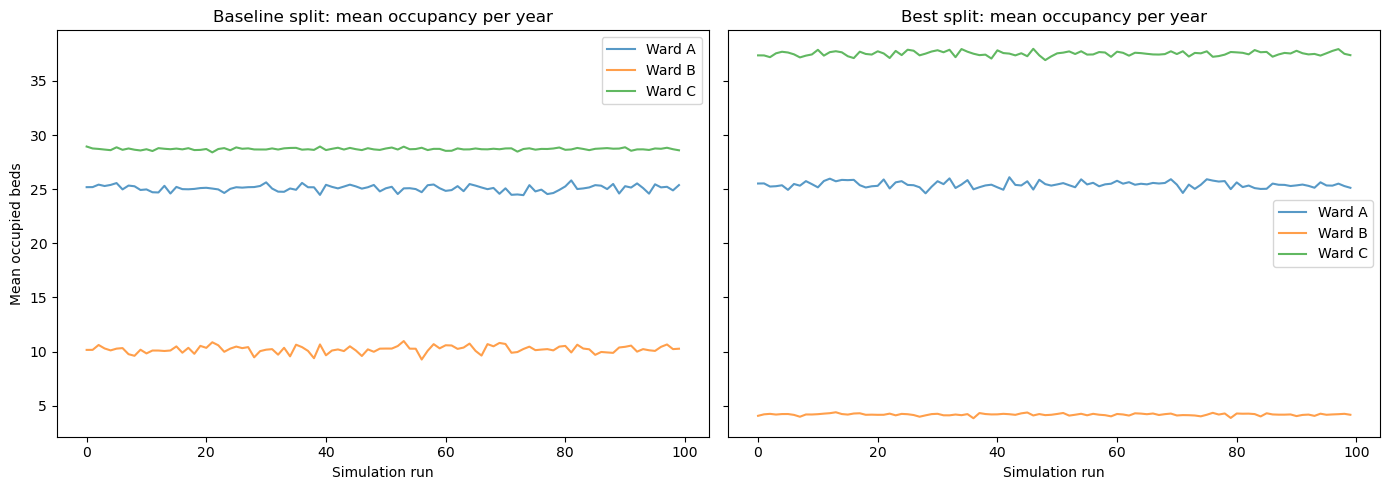

In [22]:
# Plot mean occupancy per simulation year for baseline and best distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ward in ['A', 'B', 'C']:
    axes[0].plot(baseline_results['occ_series'][ward], alpha=0.75, label=f'Ward {ward}')
axes[0].set_title('Baseline split: mean occupancy per year')
axes[0].set_xlabel('Simulation run')
axes[0].set_ylabel('Mean occupied beds')
axes[0].legend()

# Re-evaluate best split with 100 runs for a fair visual comparison
best_results_100 = evaluate_distribution(optimal_distribution, n_simulations=100)
for ward in ['A', 'B', 'C']:
    axes[1].plot(best_results_100['occ_series'][ward], alpha=0.75, label=f'Ward {ward}')
axes[1].set_title('Best split: mean occupancy per year')
axes[1].set_xlabel('Simulation run')
axes[1].legend()

plt.tight_layout()
plt.show()
